# Sesión 18: Taller de Clustering Avanzado

**Objetivos:**
-   Superar las limitaciones de K-Means (clústeres esféricos, pre-selección de K).
-   Aplicar y visualizar de forma incremental diferentes algoritmos de clustering.
-   Comparar visualmente el rendimiento de cada algoritmo en un dataset con formas complejas.

## 1. El Desafío: Datos que K-Means no Puede Manejar

K-Means es genial, pero solo ve "círculos". Hoy vamos a trabajar con un dataset diseñado para romper este supuesto. Nuestra misión es encontrar el algoritmo adecuado que sí pueda ver la estructura real de los datos.

**¡Tu primera tarea!** Ejecuta la siguiente celda para generar y visualizar el dataset con el que trabajaremos toda la sesión.

Este es nuestro campo de juego:


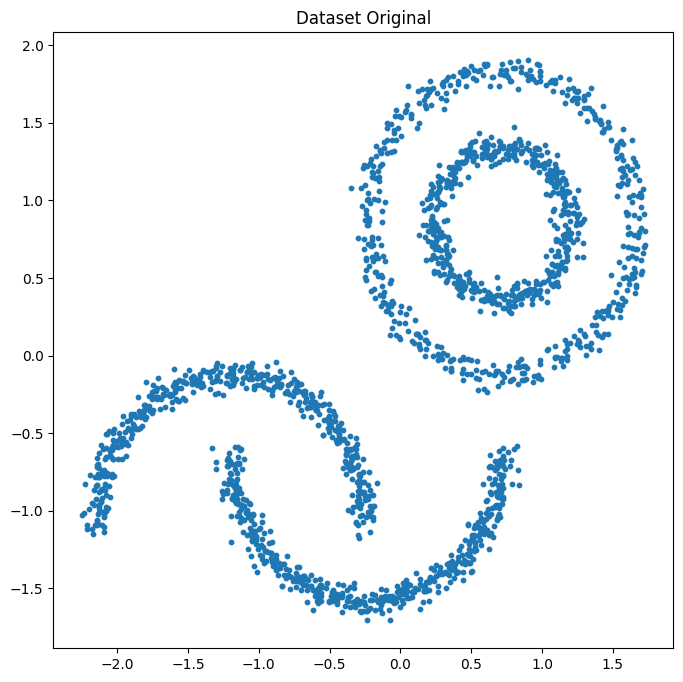

In [1]:
# --- Imports y Generación del Dataset ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
import numpy as np

# Generar un dataset complejo
n_samples = 1000
X_moons, y_moons = make_moons(n_samples=n_samples, noise=0.05, random_state=42)
X_circles, y_circles = make_circles(n_samples=n_samples, factor=0.5, noise=0.05, random_state=42)

# Unimos los datasets y los escalamos
X = np.vstack([X_moons, X_circles + 2])
X = StandardScaler().fit_transform(X)

# Visualización inicial
print("Este es nuestro campo de juego:")
plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.title('Dataset Original')
plt.show()

## 2. Línea Base: ¿Qué haría K-Means?

Ya sabemos cómo funciona K-Means. Antes de probar algoritmos nuevos, veamos cómo nuestro viejo conocido intenta resolver este problema.

**Tu tarea:** Aplica K-Means con 4 clústeres a los datos y visualiza el resultado. ¿Qué observas?

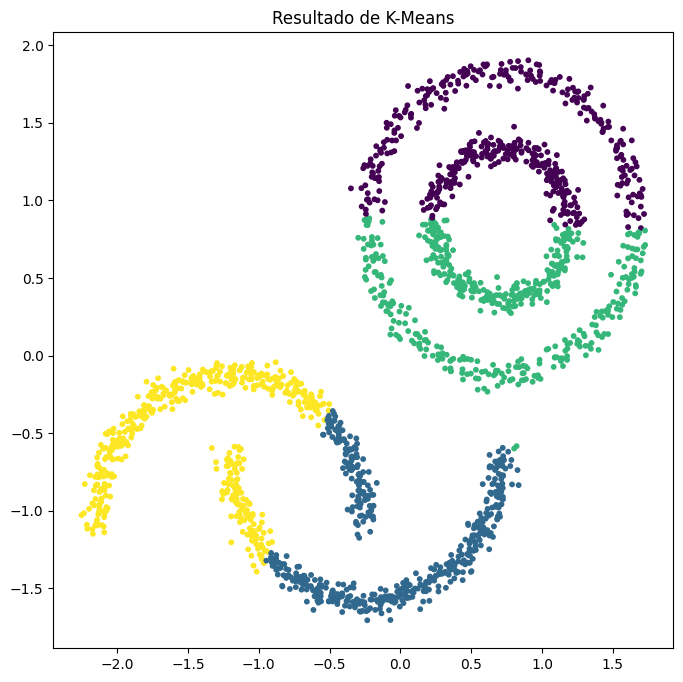

In [2]:
# --- K-Means (como línea base) ---
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

# Visualización
plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, s=10, cmap='viridis')
plt.title('Resultado de K-Means')
plt.show()

## 3. Clustering Jerárquico: El Árbol Genealógico

* **Intuición:** Este método construye una jerarquía de clústeres, como un árbol genealógico. Empieza con cada punto como una familia y va fusionando las más cercanas.
* **El Dendrograma:** Su principal herramienta es el dendrograma, que nos permite ver esta jerarquía.

**Tu tarea:** Aplica `AgglomerativeClustering` para obtener las etiquetas de 4 clústeres y visualiza el resultado.

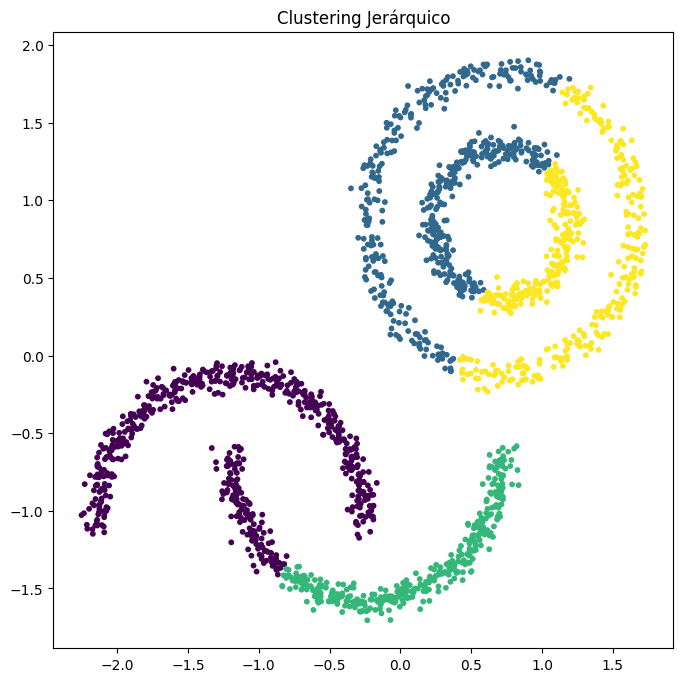

In [3]:
# --- Clustering Jerárquico (Aglomerativo) ---
# 1. Crear una instancia de AgglomerativeClustering con n_clusters=4
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')

# 2. Obtener las etiquetas con .fit_predict(X)
hierarchical_labels = hierarchical.fit_predict(X)

# 3. Crear un scatter plot usando estas nuevas etiquetas para el color
plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], c=hierarchical_labels, s=10, cmap='viridis')
plt.title('Clustering Jerárquico')
plt.show()

## 4. DBSCAN: Encontrando Constelaciones

* **Intuición:** Este algoritmo no se basa en centros, sino en **densidad**. Piensa en ello como encontrar constelaciones en el cielo: busca grupos densos de estrellas y considera las estrellas aisladas como "ruido".
* **Superpoder:** ¡Encuentra clústeres de formas arbitrarias y no necesita que le digas cuántos hay!

**Tu tarea:** Aplica `DBSCAN`. El parámetro `eps` es clave (la distancia para ser considerado "vecino"). Juega con él si quieres, pero `eps=0.15` es un buen punto de partida.

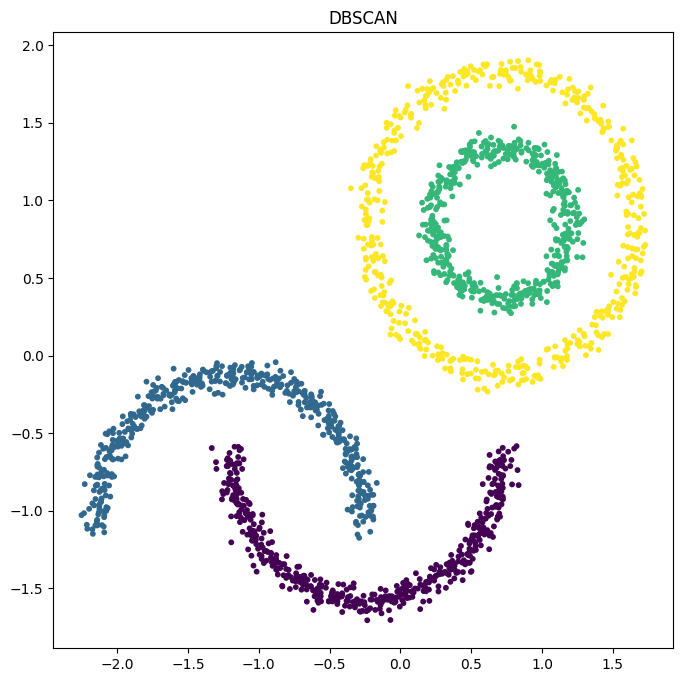

In [4]:
# --- DBSCAN ---
# 1. Crear una instancia de DBSCAN con eps=0.15
dbscan = DBSCAN(eps=0.15, min_samples=5)

# 2. Obtener las etiquetas con .fit_predict(X)
dbscan_labels = dbscan.fit_predict(X)

# 3. Crear el scatter plot coloreado por las nuevas etiquetas
plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], c=dbscan_labels, s=10, cmap='viridis')
plt.title('DBSCAN')
plt.show()
# Nota: los puntos de "ruido" tendrán la etiqueta -1

## 5. Resumen Final y Reto para Casa

Para terminar, es útil ver todos los resultados juntos.

**Tu tarea final en clase:** Modifica el código que te doy a continuación para juntar los 4 gráficos que has creado en una sola figura comparativa.

---
### 🏠 Reto para Casa: Aplicación a un Problema Real
Vuelve a usar el dataset de **"Mall Customers"** de la sesión anterior.
1.  Aplica **Clustering Jerárquico** a los datos de clientes (escalados).
2.  Genera y muestra el **dendrograma**. Según el dendrograma, ¿parece razonable "cortar" el árbol para obtener 5 clústeres?
3.  Aplica **DBSCAN** a los mismos datos. Juega con el parámetro `eps` (prueba valores entre 0.3 y 0.7). ¿Consigues encontrar una configuración que identifique grupos similares a los de K-Means? ¿Identifica algún cliente como "ruido"?
4.  **Reflexión:** De todos los algoritmos que has visto (K-Means, Jerárquico, DBSCAN), ¿cuál te parece más útil para el problema de segmentación de clientes y por qué?

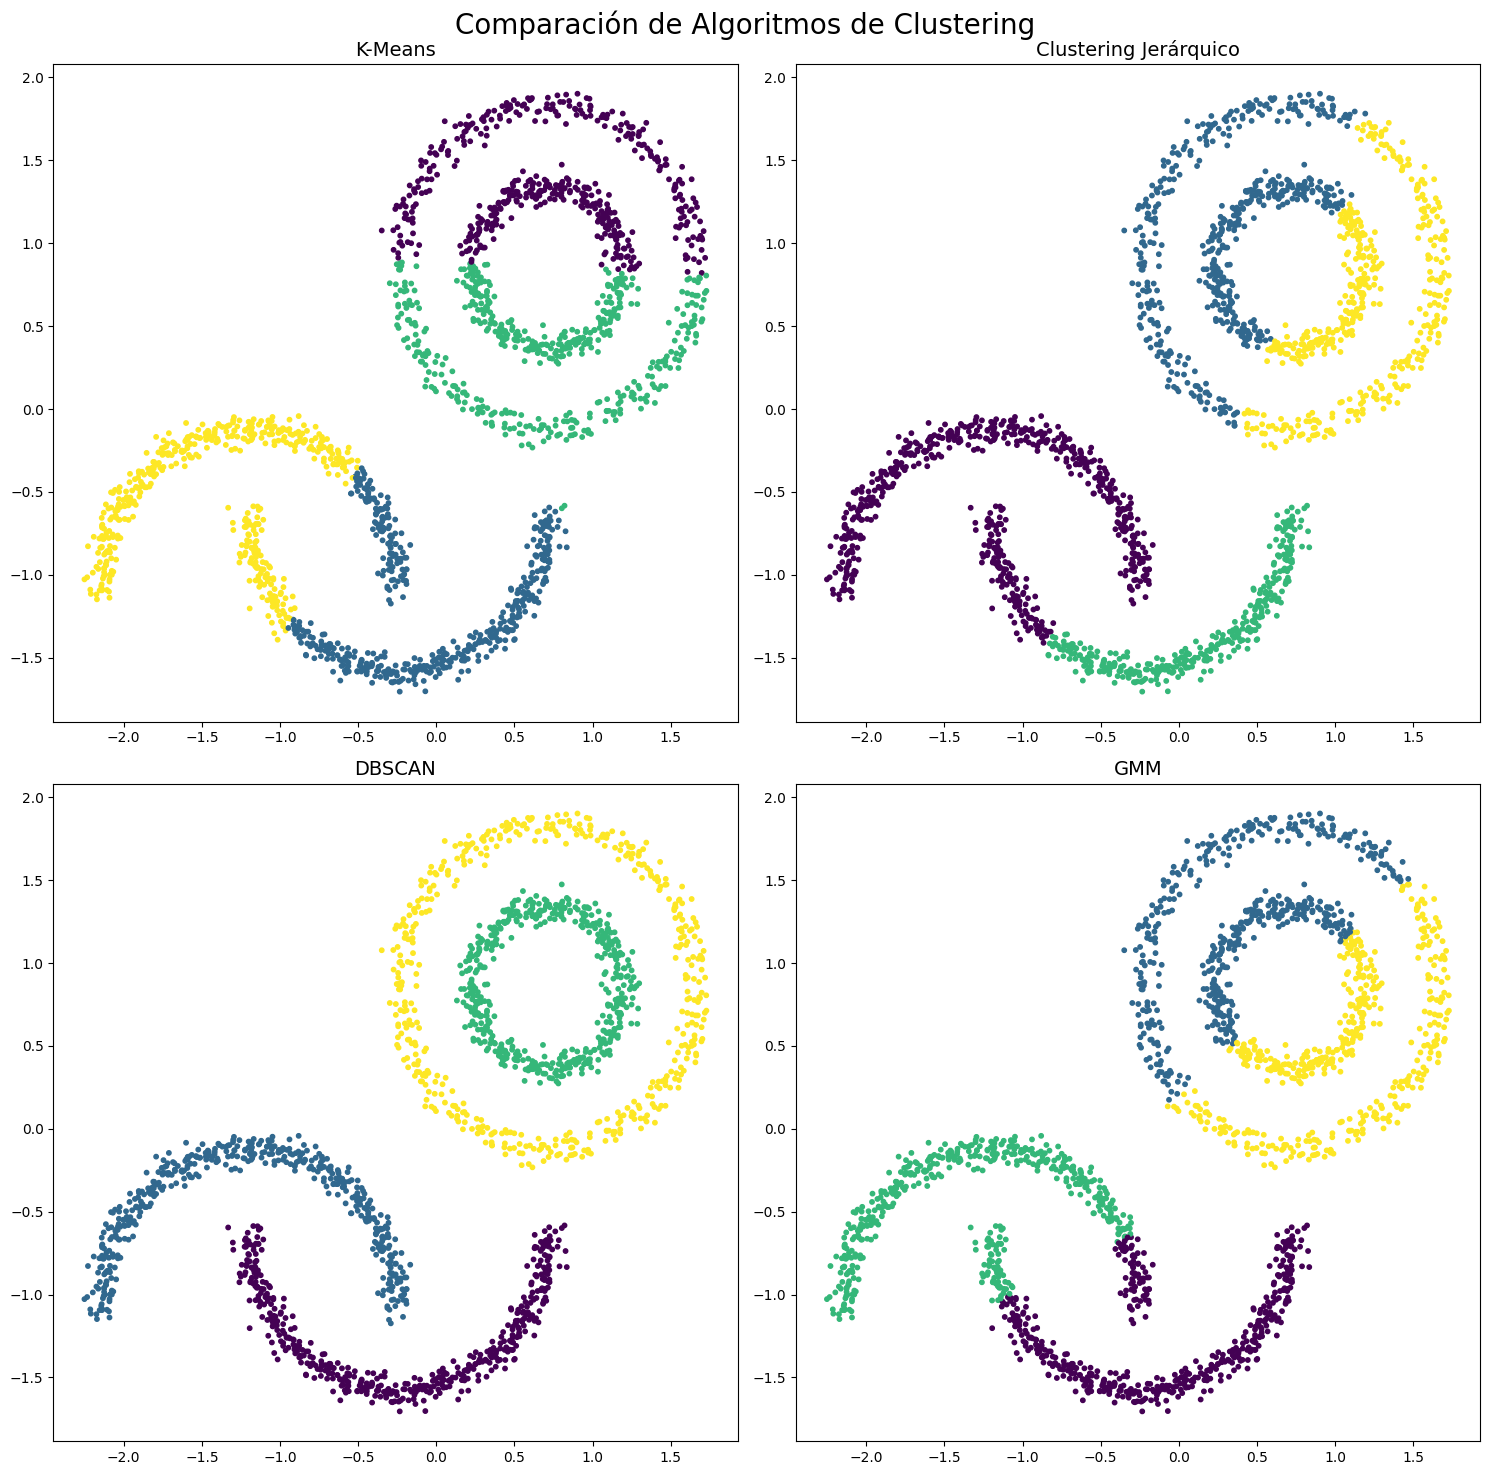

In [5]:
# --- Comparativa Final ---
# Crea una figura con 4 subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
fig.suptitle('Comparación de Algoritmos de Clustering', fontsize=20)

# K-Means en axes[0, 0]
axes[0, 0].scatter(X[:, 0], X[:, 1], c=kmeans_labels, s=10, cmap='viridis')
axes[0, 0].set_title('K-Means', fontsize=14)

# Jerárquico en axes[0, 1]
axes[0, 1].scatter(X[:, 0], X[:, 1], c=hierarchical_labels, s=10, cmap='viridis')
axes[0, 1].set_title('Clustering Jerárquico', fontsize=14)

# DBSCAN en axes[1, 0]
axes[1, 0].scatter(X[:, 0], X[:, 1], c=dbscan_labels, s=10, cmap='viridis')
axes[1, 0].set_title('DBSCAN', fontsize=14)

# GMM en axes[1, 1]
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X)
axes[1, 1].scatter(X[:, 0], X[:, 1], c=gmm_labels, s=10, cmap='viridis')
axes[1, 1].set_title('GMM', fontsize=14)

plt.tight_layout()
plt.show()

### Mis Reflexiones

*(Escribe aquí tus respuestas a las preguntas del reto para casa)*